# WT vs MUT Butterfly Wing Comparative Study

This notebook implements a unified comparison pipeline for the two butterfly wing datasets.

It covers:
- shared preprocessing for WT and MUT
- full-wing clustering and semantic area comparison
- average spectra and difference spectra
- matched MLP training and validation comparison
- WT-to-MUT and MUT-to-WT cross-domain evaluation

In [5]:
import os
import random
import warnings

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter
from skimage.morphology import remove_small_objects, erosion, disk
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import umap.umap_ as umap

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

CLASS_NAMES = {
    0: "Lower Lamina",
    1: "Cross Ribs & Ridges",
    2: "Trabeculae",
}

DATASETS = {
    "WT": {
        "path": "./bicyclus_wt_c.h5",
        "roi": (0, 170, 150, 250),
        "test_roi": (0, 170, 250, 350), 
        "bg_threshold": 0.90,
        "bg_min_size": 2000,
        "merge": {
            "Trabeculae": [20, 54, 55, 56],
            "Cross Ribs&Ridges": [12, 13, 14, 15, 16, 17, 18, 19, 21, 22, 23, 24, 25, 26, 27, 48, 49, 50, 51, 52, 53, 57, 58],
            "Lower Lamina": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 59],
        },
    },
    "MUT": {
        "path": "./bicyclus_mut_c.h5",
        "roi": (150, 350, 80, 210),
        "test_roi": (150, 350, 211, 350), 
        "bg_threshold": 1.60,
        "bg_min_size": 1000,
        "merge": {
            "Trabeculae": [55, 56, 57, 58],
            "Cross Ribs&Ridges": [27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 50, 51, 53, 54, 59],
            "Lower Lamina": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 43, 44, 45, 46, 47, 48, 49, 52],
        },
    },
}

COMMON_CFG = {
    "chosen_energy": 290.0,
    "preedge_cutoff": 285.0,
    "energy_grid": np.arange(280.0, 310.0, 1.0),
    "cluster_k": 60,
    "cluster_neighbors": 30,
    "cluster_min_dist": 0.10,
    "cluster_area_weight": 0.50,
    "test_size": 0.20,
    "batch_size": 2048,
    "max_epochs": 220,
    "lr": 5e-4,
    "weight_decay": 1e-4,
    "patience": 30,
    "hidden_dim": 512,
    "num_blocks": 6,
    "dropout": 0.10,
}

print("Common energy grid:", COMMON_CFG["energy_grid"][0], "to", COMMON_CFG["energy_grid"][-1], "eV")

Using device: cuda
Common energy grid: 280.0 to 309.0 eV


In [6]:
def circular_mean(theta, axis=0):
    return np.angle(np.mean(np.exp(1j * theta), axis=axis))


def robust_range(x, low=2, high=98):
    vals = x[np.isfinite(x)]
    if vals.size == 0:
        return 0.0, 1.0
    lo = np.nanpercentile(vals, low)
    hi = np.nanpercentile(vals, high)
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo = float(np.nanmin(vals))
        hi = float(np.nanmax(vals))
    return lo, hi


def smooth_nan_map(arr, sigma=1.2):
    mask = np.isfinite(arr).astype(np.float32)
    arr0 = np.nan_to_num(arr, nan=0.0).astype(np.float32)
    num = gaussian_filter(arr0 * mask, sigma=sigma)
    den = gaussian_filter(mask, sigma=sigma)
    out = num / np.maximum(den, 1e-8)
    out[den < 1e-6] = np.nan
    return out


def interp_cube_linear(cube, energy_src, energy_dst):
    e_in, h, w = cube.shape
    flat = cube.reshape(e_in, -1)
    interp_fn = interp1d(energy_src, flat, axis=0, kind="linear", bounds_error=False, fill_value="extrapolate")
    out = interp_fn(energy_dst).astype(np.float32)
    return out.reshape(len(energy_dst), h, w)


def interp_phase_cube(phase_cube, energy_src, energy_dst):
    sin_cube = np.sin(phase_cube)
    cos_cube = np.cos(phase_cube)
    sin_i = interp_cube_linear(sin_cube, energy_src, energy_dst)
    cos_i = interp_cube_linear(cos_cube, energy_src, energy_dst)
    return np.angle(cos_i + 1j * sin_i)


def load_and_preprocess(name, cfg, common_cfg):
    path = cfg["path"]
    assert os.path.exists(path), f"Missing file: {path}"

    with h5py.File(path, "r") as f:
        amplitude_im = np.asarray(f["amplitude"], dtype=np.float32)
        phase_im = np.asarray(f["phase"], dtype=np.float32)
        energy = np.asarray(f["energy_ev"], dtype=np.float32)

    energy_idx = int(np.argmin(np.abs(energy - common_cfg["chosen_energy"])))
    img = amplitude_im[energy_idx]

    bg_mask = img >= cfg["bg_threshold"]
    bg_mask = remove_small_objects(bg_mask, min_size=cfg["bg_min_size"])
    bg_mask = erosion(bg_mask, disk(1))

    bg_mean = amplitude_im[:, bg_mask].mean(axis=1)
    bg_phase = phase_im[:, bg_mask]
    phase_bg_mean = np.angle(np.mean(np.exp(1j * bg_phase), axis=1))

    eps = 1e-1
    bg_mean_reshape = bg_mean.reshape(-1, 1, 1)
    absorption = -2.0 * np.log((np.abs(amplitude_im) + eps) / (np.abs(bg_mean_reshape) + eps))
    phase_corrected = np.angle(np.exp(1j * (phase_im - phase_bg_mean[:, None, None])))

    absorption_masked = absorption.copy()
    absorption_masked[:, bg_mask] = np.nan
    phase_masked = phase_corrected.copy()
    phase_masked[:, bg_mask] = np.nan

    data_cube = absorption_masked.copy()
    mask_pre = energy < common_cfg["preedge_cutoff"]
    e_pre = energy[mask_pre]
    e0 = float(e_pre.min())
    d_e = e_pre - e0

    pre_flat = data_cube[mask_pre].reshape(len(e_pre), -1)
    valid_cols = np.all(np.isfinite(pre_flat), axis=0) & np.all(pre_flat > 0, axis=0)

    A_fit = np.full(pre_flat.shape[1], np.nan, dtype=np.float32)
    B_fit = np.full(pre_flat.shape[1], np.nan, dtype=np.float32)
    if np.any(valid_cols):
        y = np.log(np.maximum(pre_flat[:, valid_cols], 1e-8))
        x = d_e[:, None]
        x_mean = x.mean(axis=0)
        y_mean = y.mean(axis=0)
        cov = ((x - x_mean) * (y - y_mean)).sum(axis=0)
        var = ((x - x_mean) ** 2).sum(axis=0)
        slope = cov / np.maximum(var, 1e-8)
        intercept = y_mean - slope * x_mean
        A_fit[valid_cols] = np.exp(intercept).astype(np.float32)
        B_fit[valid_cols] = (-slope).astype(np.float32)

    h, w = bg_mask.shape
    A_fit = A_fit.reshape(h, w)
    B_fit = B_fit.reshape(h, w)
    d_e_full = (energy - e0)[:, None, None]
    preedge_baseline = A_fit[None, :, :] * np.exp(-B_fit[None, :, :] * d_e_full)
    preedge_removed = data_cube - preedge_baseline
    np.maximum(preedge_removed, 0.0, out=preedge_removed)
    preedge_removed_masked = preedge_removed.copy()
    preedge_removed_masked[:, bg_mask] = np.nan

    x1, x2, y1, y2 = cfg["roi"]
    roi_mask = np.zeros_like(bg_mask, dtype=bool)
    roi_mask[y1:y2, x1:x2] = True
    foreground_mask = ~bg_mask
    test_roi = cfg.get("test_roi", None)
    if test_roi is not None:
        tx1, tx2, ty1, ty2 = test_roi
        test_mask = foreground_mask.copy()
        test_mask[:, :] = False
        test_mask[ty1:ty2, tx1:tx2] = True
        test_mask = test_mask & foreground_mask
    else:
        test_mask = foreground_mask.copy()
        test_mask[y1:y2, x1:x2] = False

    abs_interp = interp_cube_linear(absorption_masked, energy, common_cfg["energy_grid"])
    phase_interp = interp_phase_cube(phase_masked, energy, common_cfg["energy_grid"])

    return {
        "name": name,
        "path": path,
        "energy": energy,
        "energy_interp": common_cfg["energy_grid"],
        "amplitude_im": amplitude_im,
        "phase_im": phase_im,
        "bg_mask": bg_mask,
        "foreground_mask": foreground_mask,
        "roi": (x1, x2, y1, y2),
        "roi_mask": roi_mask,
        "test_mask": test_mask,
        "absorption_masked": absorption_masked,
        "phase_masked": phase_masked,
        "preedge_removed_masked": preedge_removed_masked,
        "avg_absorbance": np.nanmean(absorption_masked, axis=0),
        "avg_preedge_removed": np.nanmean(preedge_removed_masked, axis=0),
        "abs_interp": abs_interp,
        "phase_interp": phase_interp,
    }


def cluster_full_wing(data, cfg, common_cfg):
    cube = data["preedge_removed_masked"]
    e_len, h, w = cube.shape
    x = cube.transpose(1, 2, 0).reshape(-1, e_len)
    valid = (~data["bg_mask"].reshape(-1)) & (~np.isnan(x).any(axis=1))
    xv = x[valid]

    area = xv.sum(axis=1, keepdims=True)
    xfeat = np.hstack([xv, common_cfg["cluster_area_weight"] * area])
    scaler = StandardScaler()
    xv_s = scaler.fit_transform(xfeat)

    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=common_cfg["cluster_neighbors"],
        min_dist=common_cfg["cluster_min_dist"],
        metric="euclidean",
        random_state=SEED,
    )
    emb = reducer.fit_transform(xv_s)

    kmeans = KMeans(n_clusters=common_cfg["cluster_k"], random_state=SEED, n_init="auto")
    labels_v = kmeans.fit_predict(emb)
    centers = kmeans.cluster_centers_

    start = np.argmin(centers[:, 0])
    unused = set(range(common_cfg["cluster_k"]))
    unused.remove(start)
    order = [start]
    while unused:
        last = order[-1]
        rest = np.array(list(unused))
        dists = np.linalg.norm(centers[rest] - centers[last], axis=1)
        nxt = rest[np.argmin(dists)]
        order.append(nxt)
        unused.remove(nxt)

    old_to_new = np.empty(common_cfg["cluster_k"], dtype=int)
    for new_id, old_id in enumerate(order):
        old_to_new[old_id] = new_id

    labels_v = old_to_new[labels_v]
    centers = centers[order]

    labels_flat = np.full(h * w, -1, dtype=np.int32)
    labels_flat[valid] = labels_v
    labels_full = labels_flat.reshape(h, w)

    semantic_full = np.full_like(labels_full, fill_value=-1, dtype=np.int32)
    semantic_full[np.isin(labels_full, cfg["merge"]["Lower Lamina"])] = 0
    semantic_full[np.isin(labels_full, cfg["merge"]["Cross Ribs&Ridges"])] = 1
    semantic_full[np.isin(labels_full, cfg["merge"]["Trabeculae"])] = 2

    data["task5_scaler"] = scaler
    data["umap_embedding"] = emb
    data["cluster_centers"] = centers
    data["cluster_valid_mask"] = valid.reshape(h, w)
    data["cluster_labels_full"] = labels_full
    data["semantic_full"] = semantic_full
    data["semantic_roi"] = semantic_full[data["roi"][2]:data["roi"][3], data["roi"][0]:data["roi"][1]].copy()
    return data


def mean_std_spectrum(cube, mask, energy_grid=None):
    if energy_grid is not None and cube.shape[0] != len(energy_grid):
        raise ValueError("cube first dimension does not match energy grid")
    pixels = cube[:, mask]
    return np.nanmean(pixels, axis=1), np.nanstd(pixels, axis=1)


def semantic_fraction_table(data_dict):
    rows = []
    for name, data in data_dict.items():
        fg = data["foreground_mask"]
        denom = max(int(fg.sum()), 1)
        for class_id, class_name in CLASS_NAMES.items():
            count = int(np.sum(data["semantic_full"] == class_id))
            rows.append({
                "dataset": name,
                "class_id": class_id,
                "class_name": class_name,
                "pixels": count,
                "fraction": count / denom,
            })
    return pd.DataFrame(rows)


def build_roi_semantic_mask(data, class_id):
    x1, x2, y1, y2 = data["roi"]
    out = np.zeros_like(data["foreground_mask"], dtype=bool)
    out[y1:y2, x1:x2] = data["semantic_roi"] == class_id
    return out

In [7]:
datasets = {}
for name, cfg in DATASETS.items():
    print(f"Loading and preprocessing {name} ...")
    data = load_and_preprocess(name, cfg, COMMON_CFG)
    print(f"Clustering full wing for {name} ...")
    data = cluster_full_wing(data, cfg, COMMON_CFG)
    datasets[name] = data

for name, data in datasets.items():
    x1, x2, y1, y2 = data["roi"]
    print(
        f"{name}: energy={len(data['energy'])}, foreground={int(data['foreground_mask'].sum())}, "
        f"ROI=({x1},{x2},{y1},{y2}), test_pixels={int(data['test_mask'].sum())}"
    )

Loading and preprocessing WT ...
Clustering full wing for WT ...
Loading and preprocessing MUT ...
Clustering full wing for MUT ...
WT: energy=76, foreground=83762, ROI=(0,170,150,250), test_pixels=17000
MUT: energy=77, foreground=115317, ROI=(150,350,80,210), test_pixels=27800


In [10]:
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.10):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.LayerNorm(dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.LayerNorm(dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.block(x))


class SpectralMLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden_dim=512, num_blocks=6, dropout=0.10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.blocks = nn.ModuleList([ResidualBlock(hidden_dim, dropout=dropout) for _ in range(num_blocks)])
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 192),
            nn.LayerNorm(192),
            nn.GELU(),
            nn.Dropout(0.05),
            nn.Linear(192, out_dim),
        )

    def forward(self, x):
        x = self.stem(x)
        for block in self.blocks:
            x = block(x)
        return self.head(x)


def normalize_sin_cos(out, d):
    sin_pred = out[:, :d]
    cos_pred = out[:, d:]
    norm = torch.sqrt(sin_pred ** 2 + cos_pred ** 2 + 1e-8)
    return sin_pred / norm, cos_pred / norm


def weighted_sc_loss(out, target, sample_w, d):
    sin_pred, cos_pred = normalize_sin_cos(out, d)
    sin_true = target[:, :d]
    cos_true = target[:, d:]
    loss_per_sample = (((sin_pred - sin_true) ** 2).mean(dim=1) + ((cos_pred - cos_true) ** 2).mean(dim=1)) / 2.0
    return (loss_per_sample * sample_w).sum() / sample_w.sum()


def angular_error(y_pred, y_true):
    return np.angle(np.exp(1j * (y_pred - y_true)))


def evaluate_phase(y_true, y_pred, name="set"):
    err = angular_error(y_pred, y_true)
    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err ** 2))
    cos_sim = np.mean(np.cos(err))
    r2 = r2_score(y_true.reshape(-1), y_pred.reshape(-1))
    return {
        "set": name,
        "angular_mae_rad": float(mae),
        "angular_rmse_rad": float(rmse),
        "mean_cos_error": float(cos_sim),
        "r2_supplementary": float(r2),
    }


def extract_last_latent(model, x_scaled, batch_size=4096, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    latents = []
    with torch.no_grad():
        for i in range(0, len(x_scaled), batch_size):
            xb = torch.from_numpy(x_scaled[i:i + batch_size].astype(np.float32)).to(device)
            x = model.stem(xb)
            for block in model.blocks:
                x = block(x)
            z = model.head[2](model.head[1](model.head[0](x)))
            latents.append(z.cpu().numpy())
    return np.vstack(latents)


def predict_phase(model, x_scaled, phase_ref, d, batch_size=4096, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(x_scaled), batch_size):
            xb = torch.from_numpy(x_scaled[i:i + batch_size].astype(np.float32)).to(device)
            out = model(xb)
            sin_pred, cos_pred = normalize_sin_cos(out, d)
            pred_res = np.arctan2(sin_pred.cpu().numpy(), cos_pred.cpu().numpy())
            pred_phase = np.angle(np.exp(1j * (pred_res + phase_ref[None, :])))
            preds.append(pred_phase)
    return np.vstack(preds)


def prepare_mlp_bundle(data, common_cfg):
    x1, x2, y1, y2 = data["roi"]
    x_abs_cube = data["abs_interp"][:, y1:y2, x1:x2].astype(np.float32)
    y_phase_cube = data["phase_interp"][:, y1:y2, x1:x2].astype(np.float32)
    cls_cube = data["semantic_roi"].astype(np.int32)

    d, h, w = x_abs_cube.shape
    n_total = h * w
    x_abs_full = x_abs_cube.transpose(1, 2, 0).reshape(n_total, d)
    y_phase_full = y_phase_cube.transpose(1, 2, 0).reshape(n_total, d)
    cls_full = cls_cube.reshape(-1)

    valid = np.all(np.isfinite(x_abs_full), axis=1) & np.all(np.isfinite(y_phase_full), axis=1) & (cls_full >= 0)
    x_abs_valid = x_abs_full[valid]
    y_phase_valid = y_phase_full[valid]
    cls_valid = cls_full[valid]

    if np.sum(cls_valid == 0) > 20:
        ref_mask = cls_valid == 0
        ref_name = "Lower Lamina"
    else:
        ref_mask = np.ones(len(x_abs_valid), dtype=bool)
        ref_name = "global mean"

    phase_ref = circular_mean(y_phase_valid[ref_mask], axis=0)
    y_res = np.angle(np.exp(1j * (y_phase_valid - phase_ref[None, :])))
    y_target = np.hstack([np.sin(y_res), np.cos(y_res)]).astype(np.float32)

    indices = np.arange(len(x_abs_valid))
    unique_cls, cls_counts = np.unique(cls_valid, return_counts=True)
    stratify_labels = cls_valid if (len(unique_cls) > 1 and np.min(cls_counts) >= 2) else None
    train_idx, val_idx = train_test_split(
        indices,
        test_size=common_cfg["test_size"],
        random_state=SEED,
        stratify=stratify_labels,
    )

    x_train = x_abs_valid[train_idx]
    x_val = x_abs_valid[val_idx]
    y_train = y_target[train_idx]
    y_val = y_target[val_idx]
    y_phase_val = y_phase_valid[val_idx]
    cls_train = cls_valid[train_idx]
    cls_val = cls_valid[val_idx]

    x_scaler = StandardScaler()
    x_train_s = x_scaler.fit_transform(x_train).astype(np.float32)
    x_val_s = x_scaler.transform(x_val).astype(np.float32)

    unique_cls, counts = np.unique(cls_train, return_counts=True)
    cls_count_dict = {c: n for c, n in zip(unique_cls, counts)}
    sample_weights_train = np.array([1.0 / cls_count_dict[c] for c in cls_train], dtype=np.float32)
    sample_weights_train *= len(sample_weights_train) / sample_weights_train.sum()
    sample_weights_val = np.ones(len(x_val_s), dtype=np.float32)

    bundle = {
        "dataset_name": data["name"],
        "d": d,
        "ref_name": ref_name,
        "phase_ref": phase_ref.astype(np.float32),
        "x_scaler": x_scaler,
        "x_train_s": x_train_s,
        "x_val_s": x_val_s,
        "y_train": y_train,
        "y_val": y_val,
        "y_phase_val": y_phase_val,
        "cls_train": cls_train,
        "cls_val": cls_val,
        "sample_weights_train": sample_weights_train,
        "sample_weights_val": sample_weights_val,
    }
    return bundle


def train_mlp_bundle(bundle, common_cfg):
    train_ds = TensorDataset(
        torch.from_numpy(bundle["x_train_s"]),
        torch.from_numpy(bundle["y_train"]),
        torch.from_numpy(bundle["sample_weights_train"]),
    )
    val_ds = TensorDataset(
        torch.from_numpy(bundle["x_val_s"]),
        torch.from_numpy(bundle["y_val"]),
        torch.from_numpy(bundle["sample_weights_val"]),
    )

    train_loader = DataLoader(train_ds, batch_size=common_cfg["batch_size"], shuffle=True, drop_last=False)
    val_loader = DataLoader(val_ds, batch_size=common_cfg["batch_size"], shuffle=False, drop_last=False)

    model = SpectralMLP(
        in_dim=bundle["x_train_s"].shape[1],
        out_dim=2 * bundle["d"],
        hidden_dim=common_cfg["hidden_dim"],
        num_blocks=common_cfg["num_blocks"],
        dropout=common_cfg["dropout"],
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=common_cfg["lr"], weight_decay=common_cfg["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

    best_val = np.inf
    best_state = None
    wait = 0
    history = []

    for epoch in range(1, common_cfg["max_epochs"] + 1):
        model.train()
        train_loss_sum = 0.0
        train_n = 0
        for xb, yb, wb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            wb = wb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = weighted_sc_loss(out, yb, wb, bundle["d"])
            loss.backward()
            optimizer.step()
            train_loss_sum += loss.item() * len(xb)
            train_n += len(xb)
        train_loss = train_loss_sum / train_n

        model.eval()
        val_loss_sum = 0.0
        val_n = 0
        with torch.no_grad():
            for xb, yb, wb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                wb = wb.to(device)
                out = model(xb)
                loss = weighted_sc_loss(out, yb, wb, bundle["d"])
                val_loss_sum += loss.item() * len(xb)
                val_n += len(xb)
        val_loss = val_loss_sum / val_n
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})
        scheduler.step(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= common_cfg["patience"]:
                break

    model.load_state_dict(best_state)

    y_val_pred = predict_phase(model, bundle["x_val_s"], bundle["phase_ref"], bundle["d"], device=device)
    rows = [evaluate_phase(bundle["y_phase_val"], y_val_pred, name=f"{bundle['dataset_name']} Validation")]
    for class_id in np.unique(bundle["cls_val"]):
        m = bundle["cls_val"] == class_id
        metrics_c = evaluate_phase(bundle["y_phase_val"][m], y_val_pred[m], name=CLASS_NAMES[int(class_id)])
        metrics_c["dataset"] = bundle["dataset_name"]
        metrics_c["class_id"] = int(class_id)
        metrics_c["class_name"] = CLASS_NAMES[int(class_id)]
        metrics_c["n_pixels"] = int(m.sum())
        rows.append(metrics_c)

    bundle["model"] = model
    bundle["history_df"] = pd.DataFrame(history)
    bundle["validation_metrics_df"] = pd.DataFrame(rows)
    bundle["latent_val"] = extract_last_latent(model, bundle["x_val_s"], device=device)
    bundle["latent_val_2d"] = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, metric="euclidean", random_state=SEED).fit_transform(bundle["latent_val"])
    return bundle


def evaluate_bundle_on_mask(bundle, target_data, mask, eval_name):
    x_abs_cube = target_data["abs_interp"]
    y_phase_cube = target_data["phase_interp"]
    semantic_full = target_data["semantic_full"]

    d, h, w = x_abs_cube.shape
    x_abs_full = x_abs_cube.transpose(1, 2, 0).reshape(h * w, d)
    y_phase_full = y_phase_cube.transpose(1, 2, 0).reshape(h * w, d)
    cls_full = semantic_full.reshape(-1)
    mask_flat = mask.reshape(-1)

    valid = mask_flat & np.all(np.isfinite(x_abs_full), axis=1) & np.all(np.isfinite(y_phase_full), axis=1) & (cls_full >= 0)
    x_valid = x_abs_full[valid].astype(np.float32)
    y_phase_valid = y_phase_full[valid]
    cls_valid = cls_full[valid]

    if len(x_valid) == 0:
        return {
            "metrics_df": pd.DataFrame(),
            "mae_map": np.full((h, w), np.nan, dtype=np.float32),
            "valid_mask": np.zeros((h, w), dtype=bool),
        }

    x_scaled = bundle["x_scaler"].transform(x_valid).astype(np.float32)
    y_pred = predict_phase(bundle["model"], x_scaled, bundle["phase_ref"], bundle["d"], device=device)

    rows = [evaluate_phase(y_phase_valid, y_pred, name=eval_name)]
    rows[0]["dataset"] = target_data["name"]
    rows[0]["source_model"] = bundle["dataset_name"]
    rows[0]["n_pixels"] = int(len(x_valid))
    for class_id in np.unique(cls_valid):
        m = cls_valid == class_id
        metrics_c = evaluate_phase(y_phase_valid[m], y_pred[m], name=f"{eval_name} | {CLASS_NAMES[int(class_id)]}")
        metrics_c["dataset"] = target_data["name"]
        metrics_c["source_model"] = bundle["dataset_name"]
        metrics_c["class_id"] = int(class_id)
        metrics_c["class_name"] = CLASS_NAMES[int(class_id)]
        metrics_c["n_pixels"] = int(m.sum())
        rows.append(metrics_c)

    err = angular_error(y_pred, y_phase_valid)
    mae_per_pixel = np.mean(np.abs(err), axis=1)
    mae_map = np.full(h * w, np.nan, dtype=np.float32)
    mae_map[valid] = mae_per_pixel
    mae_map = mae_map.reshape(h, w)

    return {
        "metrics_df": pd.DataFrame(rows),
        "mae_map": mae_map,
        "valid_mask": valid.reshape(h, w),
    }

In [ ]:
mlp_bundles = {}
for name in ["WT", "MUT"]:
    print(f"Preparing ROI training bundle for {name} ...")
    bundle = prepare_mlp_bundle(datasets[name], COMMON_CFG)
    print(f"Training MLP for {name} with reference: {bundle['ref_name']}")
    bundle = train_mlp_bundle(bundle, COMMON_CFG)
    mlp_bundles[name] = bundle


In [ ]:
# --------------------------------------------------
# 9) Joint latent helper for the final MUT UMAP view
# --------------------------------------------------

def get_joint_latent(source_model):
    latents, labels, domains = [], [], []
    for target_name in ["WT", "MUT"]:
        target = datasets[target_name]
        mask = target["test_mask"].reshape(-1)
        x_abs = target["abs_interp"].transpose(1, 2, 0).reshape(-1, len(target["energy_interp"]))
        cls = target["semantic_full"].reshape(-1)
        valid = mask & np.all(np.isfinite(x_abs), axis=1) & (cls >= 0)
        if not np.any(valid):
            continue

        x_scaled = mlp_bundles[source_model]["x_scaler"].transform(
            x_abs[valid].astype(np.float32)
        ).astype(np.float32)
        latents.append(
            extract_last_latent(
                mlp_bundles[source_model]["model"],
                x_scaled,
                device=device,
            )
        )
        labels.append(cls[valid])
        domains.append(np.full(np.sum(valid), target_name, dtype=object))

    latent_2d = umap.UMAP(
        n_components=2,
        n_neighbors=30,
        min_dist=0.1,
        metric="euclidean",
        random_state=SEED,
    ).fit_transform(np.vstack(latents))
    return latent_2d, np.concatenate(labels), np.concatenate(domains)


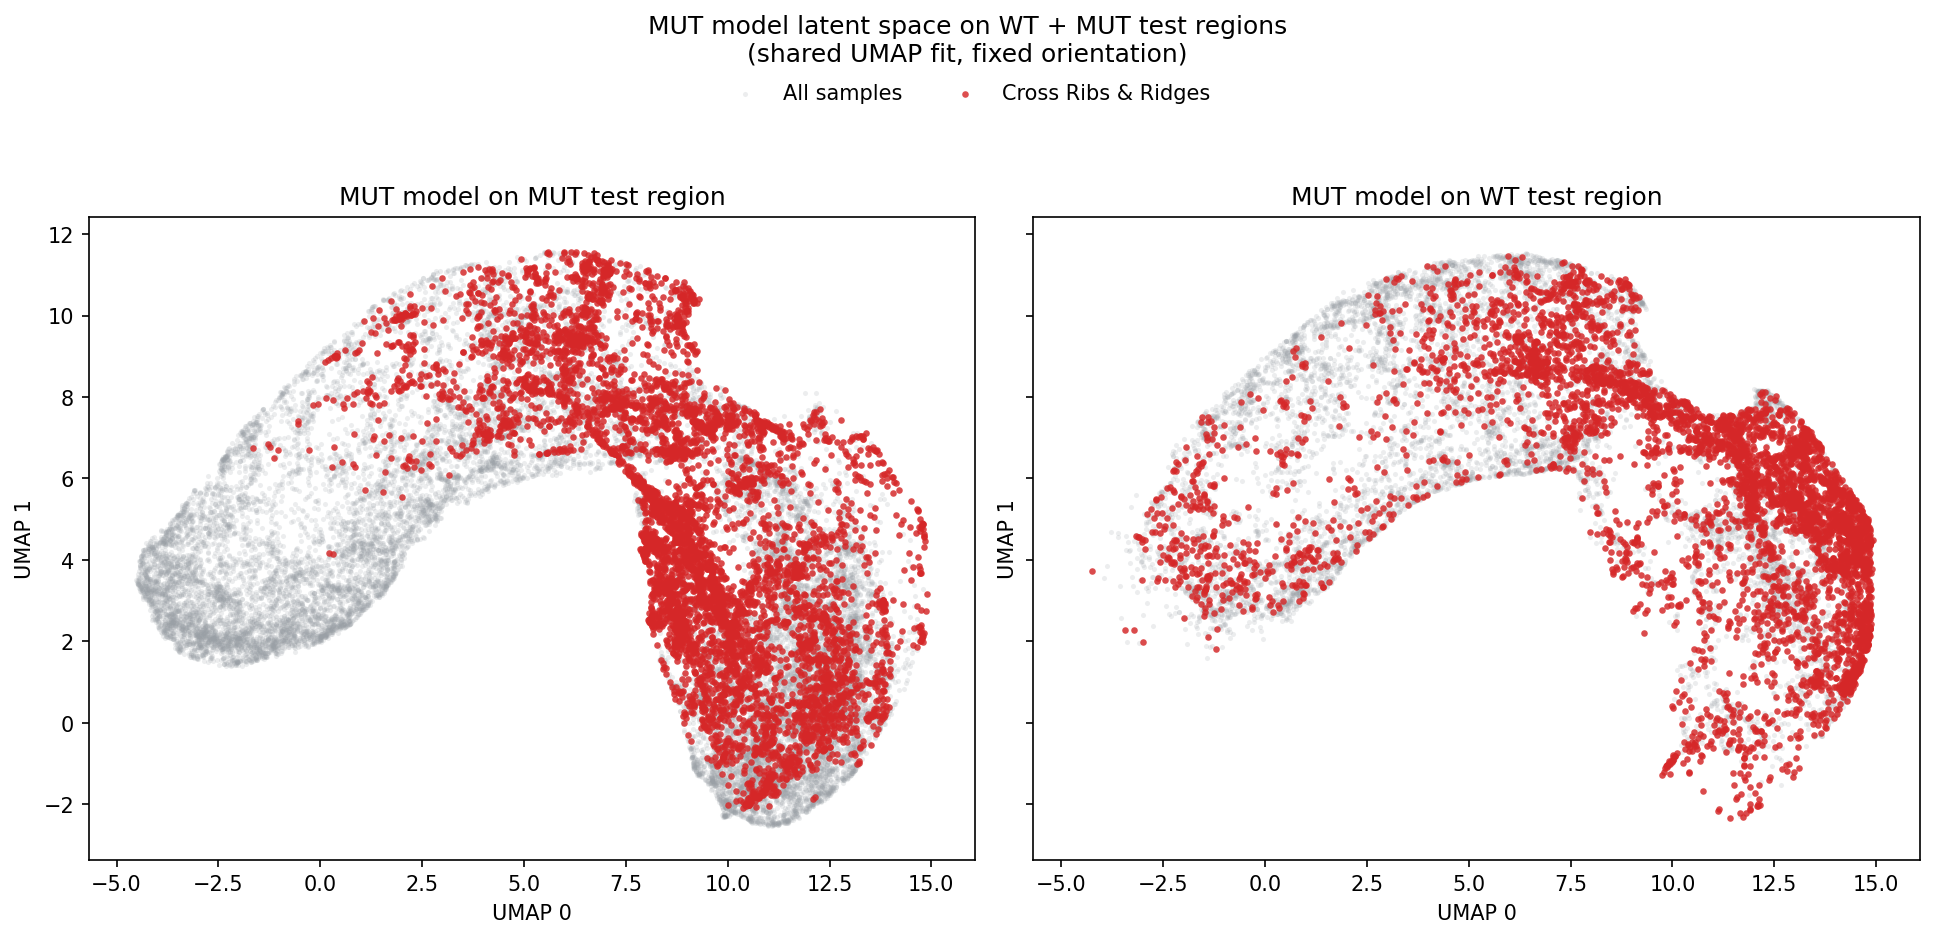

In [14]:
# --------------------------------------------------
# 10) MUT model latent space on test regions
# Shared UMAP + fixed orientation for direct comparison
# --------------------------------------------------

highlight_class_id = 1
highlight_class_name = CLASS_NAMES[highlight_class_id]


def orient_embedding(embedding, labels, domains, ref_domain="MUT", ref_class=1):
    emb = embedding.copy()
    ref_mask = (domains == ref_domain) & (labels == ref_class)
    if not np.any(ref_mask):
        return emb

    global_center = emb.mean(axis=0)
    ref_center = emb[ref_mask].mean(axis=0)
    delta = ref_center - global_center

    # Force a stable left-right / up-down orientation for visual comparison.
    if delta[0] < 0:
        emb[:, 0] *= -1
    if delta[1] < 0:
        emb[:, 1] *= -1
    return emb


mut_latent_2d, mut_labels, mut_domains = get_joint_latent("MUT")
mut_latent_2d = orient_embedding(
    mut_latent_2d,
    mut_labels,
    mut_domains,
    ref_domain="MUT",
    ref_class=highlight_class_id,
)

x_min, y_min = mut_latent_2d.min(axis=0)
x_max, y_max = mut_latent_2d.max(axis=0)
pad_x = 0.06 * max(x_max - x_min, 1e-6)
pad_y = 0.06 * max(y_max - y_min, 1e-6)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), dpi=150, sharex=True, sharey=True)

panel_specs = [
    ("MUT", "MUT model on MUT test region"),
    ("WT", "MUT model on WT test region"),
]

for ax, (domain_name, title) in zip(axes, panel_specs):
    domain_mask = mut_domains == domain_name
    highlight_mask = domain_mask & (mut_labels == highlight_class_id)

    ax.scatter(
        mut_latent_2d[domain_mask, 0],
        mut_latent_2d[domain_mask, 1],
        s=6,
        alpha=0.18,
        color="#9AA0A6",
        linewidths=0,
        label="All samples",
    )
    ax.scatter(
        mut_latent_2d[highlight_mask, 0],
        mut_latent_2d[highlight_mask, 1],
        s=10,
        alpha=0.82,
        color="#D62728",
        linewidths=0,
        label=highlight_class_name,
    )

    ax.set_title(title)
    ax.set_xlabel("UMAP 0")
    ax.set_ylabel("UMAP 1")
    ax.set_xlim(x_min - pad_x, x_max + pad_x)
    ax.set_ylim(y_min - pad_y, y_max + pad_y)
    ax.set_aspect("equal", adjustable="box")

legend_handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    legend_handles,
    legend_labels,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
)
fig.suptitle(
    "MUT model latent space on WT + MUT test regions\n(shared UMAP fit, fixed orientation)",
    y=1.08,
)
plt.tight_layout()
plt.show()